# Phase 3 — Baseline CNN

## Purpose
We train a simple CNN built entirely from scratch — no pretrained weights,
no borrowed knowledge from other datasets.

This model is our **benchmark**. Every transfer learning model in Phase 4
must outperform it to justify the added complexity.

## What this notebook covers
1. Load the preprocessing pipeline from Phase 2
2. Build the baseline CNN architecture
3. Set up training callbacks (early stopping, checkpointing, LR reduction)
4. Train the model and monitor progress
5. Plot training and validation accuracy / loss curves
6. Save the best model to `saved_models/`
7. Record baseline results for Phase 5 comparison

## Model architecture
- 4 × Convolutional Blocks (Conv2D → BatchNorm → ReLU → MaxPool)
- GlobalAveragePooling2D
- Dense(128) → Dropout(0.5) → Dense(3, softmax)

## Step 1 — Imports

In [2]:
import os
os.add_dll_directory(r"C:\Users\ahmed\anaconda3\envs\lung_cancer\Library\bin")

import sys
import numpy as np
import matplotlib.pyplot as plt

# Add project root to path so we can import from src/
sys.path.append(os.path.abspath(".."))

from src.data_preprocessing import get_data_generators, IMG_SIZE, BATCH_SIZE
from src.model_baseline import build_baseline_model

import tensorflow as tf

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version : 2.10.0
GPU available      : True


## Step 2 — Load Data Generators

We reuse the exact same preprocessing pipeline from Phase 2.
No new splitting or loading logic — everything comes from `data_preprocessing.py`.

In [3]:
DATA_DIR = r"../data/lung_image_sets"

train_gen, val_gen, test_gen = get_data_generators(
    data_dir   = DATA_DIR,
    img_size   = IMG_SIZE,
    batch_size = BATCH_SIZE
)

Found 10500 validated image filenames belonging to 3 classes.
Found 2250 validated image filenames belonging to 3 classes.
Found 2250 validated image filenames belonging to 3 classes.
───────────────────────────────────────────────────────
  Data Generators Ready
───────────────────────────────────────────────────────
  Image size             : 224 × 224 px
  Batch size             : 32
  Rescaling              : [0,1]
  Preprocessing function : None
  Train samples          : 10500
  Val   samples          : 2250
  Test  samples          : 2250
  Classes                : {'lung_aca': 0, 'lung_n': 1, 'lung_scc': 2}
───────────────────────────────────────────────────────


## Step 3 — Build the Model

We call `build_baseline_model()` and print a summary.
The summary shows every layer, its output shape, and how many
trainable parameters it has.

**What are parameters?**
Parameters are the numbers the model learns during training —
the weights inside each Conv2D and Dense layer. More parameters
means more capacity to learn, but also more risk of overfitting
and more memory usage.

In [4]:
model = build_baseline_model(
    input_shape = (IMG_SIZE[0], IMG_SIZE[1], 3),   # (224, 224, 3)
    num_classes = 3
)

# Print full architecture summary
# "Total params" tells us how large the model is
# "Trainable params" = parameters that will be updated during training
model.summary()

Model: "baseline_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv (Conv2D)        (None, 224, 224, 32)      864       
                                                                 
 block1_bn (BatchNormalizati  (None, 224, 224, 32)     128       
 on)                                                             
                                                                 
 block1_relu (Activation)    (None, 224, 224, 32)      0         
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 32)      0         
                                                                 
 block2_conv (Conv2D)        (None, 112, 112, 64)      18432     
                                                      

## Step 4 — Training Callbacks

Callbacks are functions that run automatically at the end of each epoch.
We use three:

### EarlyStopping
Monitors validation accuracy. If it doesn't improve for 5 consecutive
epochs, training stops automatically. This prevents wasting time and
avoids overfitting on extra unnecessary epochs.
`restore_best_weights=True` means the model automatically rolls back
to the best weights it ever saw — not the final ones.

### ModelCheckpoint
Saves the model to disk every time validation accuracy improves.
At the end of training, `saved_models/baseline_cnn_best.keras` holds
the single best model across all epochs.

### ReduceLROnPlateau
If validation loss stops improving for 3 epochs, the learning rate
is multiplied by 0.5 (halved). A smaller learning rate helps the model
make finer adjustments and escape plateaus.

In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Create the folder where models will be saved if it doesn't exist yet
os.makedirs("../saved_models", exist_ok=True)

callbacks = [

    EarlyStopping(
        monitor              = "val_accuracy",  # Watch validation accuracy
        patience             = 5,               # Stop after 5 epochs of no improvement
        restore_best_weights = True,            # Roll back to the best weights
        verbose              = 1                # Print a message when triggered
    ),

   ModelCheckpoint(
    filepath         = "../saved_models/baseline_cnn_best.keras",
    monitor           = "val_accuracy",
    save_best_only    = True,
    save_weights_only = True,
    verbose           = 1
),

    ReduceLROnPlateau(
        monitor  = "val_loss",
        factor   = 0.5,       # Multiply learning rate by 0.5 when triggered
        patience = 3,         # Wait 3 epochs before reducing
        min_lr   = 1e-6,      # Never reduce below this value
        verbose  = 1
    )

]

print("✅ Callbacks ready.")

✅ Callbacks ready.


## Step 5 — Train the Model

We call `model.fit()` which runs the full training loop:

For each epoch:
1. Feed training images through the model in batches of 32
2. Compute the loss (how wrong the predictions were)
3. Backpropagate — calculate how much each weight contributed to the error
4. Update all weights using the Adam optimizer
5. After all training batches: evaluate on the validation set (no weight updates)
6. Run callbacks (check for improvement, save model if needed)

`steps_per_epoch` tells Keras how many batches make one epoch.
We compute it as total_training_images / batch_size.

In [7]:
EPOCHS = 30   # Maximum epochs — EarlyStopping will likely stop before this

history = model.fit(
    train_gen,
    epochs          = EPOCHS,
    steps_per_epoch = train_gen.n // BATCH_SIZE,   # 10500 // 32 = 328 steps/epoch
    validation_data = val_gen,
    validation_steps = val_gen.n // BATCH_SIZE,    # 2250 // 32 = 70 steps/epoch
    callbacks       = callbacks,
    verbose         = 1
)

print("\n✅ Training complete.")

Epoch 1/30
328/328 [==============================] - ETA: 0s - loss: 0.2988 - accuracy: 0.8770
Epoch 1: val_accuracy improved from -inf to 0.38884, saving model to ../saved_models\baseline_cnn_best.keras
328/328 [==============================] - 327s 959ms/step - loss: 0.2988 - accuracy: 0.8770 - val_loss: 1.6410 - val_accuracy: 0.3888 - lr: 0.0010
Epoch 2/30
328/328 [==============================] - ETA: 0s - loss: 0.2288 - accuracy: 0.9095
Epoch 2: val_accuracy improved from 0.38884 to 0.89554, saving model to ../saved_models\baseline_cnn_best.keras
328/328 [==============================] - 310s 946ms/step - loss: 0.2288 - accuracy: 0.9095 - val_loss: 0.2565 - val_accuracy: 0.8955 - lr: 0.0010
Epoch 3/30
328/328 [==============================] - ETA: 0s - loss: 0.2164 - accuracy: 0.9147
Epoch 3: val_accuracy did not improve from 0.89554
328/328 [==============================] - 297s 906ms/step - loss: 0.2164 - accuracy: 0.9147 - val_loss: 0.4410 - val_accuracy: 0.8094 - lr: 0.0

## Step 6 — Training Curves

We plot accuracy and loss over epochs for both train and validation sets.

**What to look for:**
- **Good training**: both curves improve together and converge
- **Overfitting**: training accuracy keeps rising but validation accuracy
  plateaus or drops — the model memorized training data but can't generalize
- **Underfitting**: both curves are low — the model didn't learn enough

The gap between the training and validation curves tells us how much
the model is overfitting.

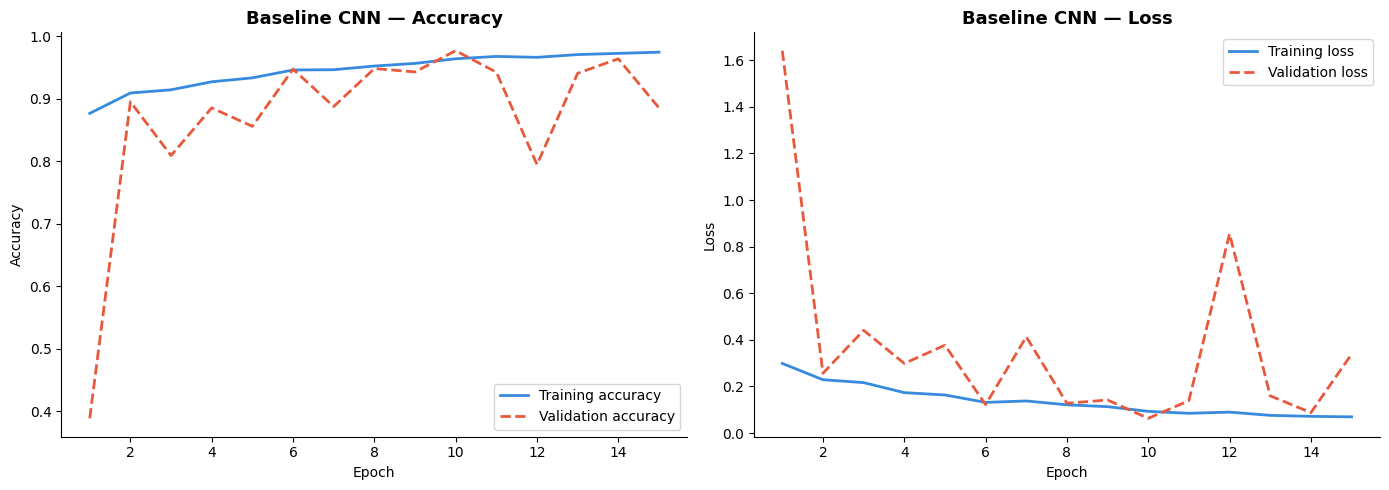

💾 Saved → results/baseline_cnn_training_curves.png


In [8]:
def plot_training_history(history, model_name="Baseline CNN"):
    """
    Plots accuracy and loss curves for training and validation sets.

    Args:
        history    : The History object returned by model.fit()
        model_name : Title label for the plot
    """
    acc      = history.history["accuracy"]
    val_acc  = history.history["val_accuracy"]
    loss     = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs   = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Accuracy plot ────────────────────────────────────────────
    axes[0].plot(epochs, acc,     color="#378ADD", linewidth=2,
                 label="Training accuracy")
    axes[0].plot(epochs, val_acc, color="#E8593C", linewidth=2,
                 linestyle="--", label="Validation accuracy")
    axes[0].set_title(f"{model_name} — Accuracy", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].spines[["top", "right"]].set_visible(False)

    # ── Loss plot ────────────────────────────────────────────────
    axes[1].plot(epochs, loss,     color="#378ADD", linewidth=2,
                 label="Training loss")
    axes[1].plot(epochs, val_loss, color="#E8593C", linewidth=2,
                 linestyle="--", label="Validation loss")
    axes[1].set_title(f"{model_name} — Loss", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"../results/baseline_cnn_training_curves.png", dpi=150)
    plt.show()
    print("💾 Saved → results/baseline_cnn_training_curves.png")


plot_training_history(history)

## Step 7 — Evaluate on Validation Set

We evaluate the best saved model (restored by EarlyStopping) on the
validation set to get a final accuracy score.

**Important:** We do NOT evaluate on the test set here. The test set
is reserved exclusively for Phase 5, where we compare all models
on a level playing field.

In [ ]:
# Evaluate on the validation set
val_loss, val_accuracy = model.evaluate(
    val_gen,
    steps   = val_gen.n // BATCH_SIZE,
    verbose = 1
)

print("\n" + "─" * 45)
print("  Baseline CNN — Validation Results")
print("─" * 45)
print(f"  Validation accuracy : {val_accuracy * 100:.2f}%")
print(f"  Validation loss     : {val_loss:.4f}")
print("─" * 45)
# Re-save baseline weights as numpy for consistent loading across all phases
# No retraining needed — we just convert the existing saved weights

import numpy as np

# Rebuild the architecture
baseline_model_reload = build_baseline_model(input_shape=(224, 224, 3), num_classes=3)

# Load from the existing .keras checkpoint
baseline_model_reload.load_weights("../saved_models/baseline_cnn_best.keras")

# Save as numpy — same format used by all transfer learning models
weights = baseline_model_reload.get_weights()
np.save(
    "../saved_models/baseline_cnn_weights.npy",
    np.array(weights, dtype=object),
    allow_pickle=True
)

print(f"✅ Baseline weights re-saved as numpy")
print(f"   Weight tensors saved : {len(weights)}")
print(f"   File → saved_models/baseline_cnn_weights.npy")

70/70 [==============================] - 17s 242ms/step - loss: 0.0631 - accuracy: 0.9772

─────────────────────────────────────────────
  Baseline CNN — Validation Results
─────────────────────────────────────────────
  Validation accuracy : 97.72%
  Validation loss     : 0.0631
─────────────────────────────────────────────
  Model saved → saved_models/baseline_cnn_best.keras


## Summary

| Item | Value |
|---|---|
| Architecture | Custom CNN — 4 Conv Blocks + GAP + Dense |
| Input size | 224 × 224 × 3 |
| Training samples | 10,500 |
| Validation samples | 2,250 |
| Optimizer | Adam (lr=0.001) |
| Best model saved | `saved_models/baseline_cnn_best.keras` |
| Training curves saved | `results/baseline_cnn_training_curves.png` |

## What Comes Next — Phase 4: Transfer Learning

With the baseline score established, we now fine-tune three pretrained
models — EfficientNetB0, InceptionV3, and ResNet50 — and compare their
performance against this baseline in Phase 5.

✅ Baseline weights re-saved as numpy
   Weight tensors saved : 24
   File → saved_models/baseline_cnn_weights.npy
